In [1]:
import os
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

from utils.model_io import load_model
from utils.comparison.comparison import *

cur_dir = Path(os.getcwd()).resolve()
proj_dir = next(parent for parent in [cur_dir, *cur_dir.parents] if (parent / "utils").exists() and (parent / "data").exists())

MODELS_DIR = proj_dir / "saved_models" / "task_1"
DATA_PATH = proj_dir / "data" / "split" / "task_1"
SAVE_PLOT_PATH = proj_dir / "doc" / "src" / "models"
SAVE = True

# Comparison
import the best models and use the trained models to all subjects provided, in order to see whether the model is able to generalize


## 1. Load best models find for the task
Searches the 'saved_models' directory for the best-performing model. It extracts the subject ID and algorithm name from the filename to contextualize the cross-subject test.

In [2]:
# find all available best models
model_files = list(MODELS_DIR.glob("*.joblib"))
if not model_files:
    raise FileNotFoundError(f"No models found in {MODELS_DIR}")
# there is only one model, select the first
model_path = model_files[0] 

# extract metadata from the model filename (format: chbNN_ModelName_best_model.joblib)
model_filename = model_path.stem
SELECTED_SUBJECT = model_filename.split("_")[0]
MODEL_TYPE = model_filename.split("_")[1]

print(f"COMPARISON OF:")
print(f"\tModel Path: {model_path}")
print(f"\tTrained on: {SELECTED_SUBJECT} ({MODEL_TYPE})")

# load model object
model = load_model(model_path)

COMPARISON OF:
	Model Path: C:\Users\aless\Desktop\EEG-epileptic-seizures-detection\saved_models\task_1\chb04_KNN_best_model.joblib
	Trained on: chb04 (KNN)


## 2. Load data of the subjects
Defines the helper function to load and 'pool' recordings and extract the subjects data from the files.

In [ ]:
def load_and_pool_subject(subj_id):
    """
    Simulates the pooling/loading logic required by the model.
    Loads all .npz files for a specific subject.
    """
    subj_path = DATA_PATH / subj_id
    files = sorted(list(subj_path.glob("*.npz")))
    
    all_frames = []
    for f_path in files:
        data = np.load(f_path, allow_pickle=True)
        # take all windows from the 'test' split 
        X_test = data["X_test"]
        y_test = data["y_test"]
        feature_names = data["feature_names"]
        
        df = pd.DataFrame(X_test, columns=feature_names)
        df["is_seizure"] = y_test
        all_frames.append(df)
        
    return pd.concat(all_frames, ignore_index=True)

In [4]:
# map subjects and their respective files
# Dict format: {'chb01': [file1, file2...], 'chb02': [...]}
SUBJECTS_DIRECTORIES = {
    subj.name: sorted([f.stem for f in subj.glob("*.npz")])
    for subj in DATA_PATH.iterdir() if subj.is_dir()
}

## 3. Perform cross-subject evaluation
Iterates through every subject in the dataset. For each subject: performs data preprocessing (scaling and feature selection), generates predictions, and calculates metrics focused on seizure detection accuracy (Recall, Precision, and F1-score).

In [ ]:
print(f"\nStarting cross-subject evaluation...")
results = []
eval_data = {}

for subj_name in tqdm(SUBJECTS_DIRECTORIES.keys(), desc="Evaluating Subjects"):
    try:
        print(f"\nLoading subject {subj_name} recordings...")
        df_subj = load_and_pool_subject(subj_name)

        # preprocess data
        X, y = model.preprocess(df_subj, is_training=False, verbose=True)

        # make predictions
        y_pred = model.predict(X)
        scores = model.predict_proba(X) if hasattr(model, 'predict_proba') else None

        # store data for confusion matrix
        eval_data[subj_name] = {"y_true": y, "y_pred": y_pred}

        results.append({
            "subject": subj_name,
            "samples": len(y),
            "seizure_samples": np.sum(y),
            "accuracy": accuracy_score(y, y_pred),
            "precision": precision_score(y, y_pred, average="weighted", zero_division=0),
            "recall": recall_score(y, y_pred, average="weighted", zero_division=0),
            "f1": f1_score(y, y_pred, average="weighted", zero_division=0),
            "precision_seizure": precision_score(y, y_pred, pos_label=1, zero_division=0),
            "recall_seizure": recall_score(y, y_pred, pos_label=1, zero_division=0),
            "f1_seizure": f1_score(y, y_pred, pos_label=1, zero_division=0),
            "roc_auc": np.nan,
        })

        if scores is not None and len(np.unique(y)) == 2:
            results["roc_auc"] = roc_auc_score(y, scores)
    except Exception as e:
        print(f"Error evaluating {subj_name}: {e}")



Starting cross-subject evaluation...


Evaluating Subjects:   0%|          | 0/4 [00:00<?, ?it/s]


Loading subject chb04 recordings...
[KNN] Features shape: (4034, 627), Labels shape: (4034,)
Label distribution:
is_seizure
0.0    1.0
Name: proportion, dtype: float64
[KNN] Applying pre-selected 15 features.

Loading subject chb12 recordings...
[KNN] Features shape: (2100, 837), Labels shape: (2100,)
Label distribution:
is_seizure
0.0    0.993333
1.0    0.006667
Name: proportion, dtype: float64
[KNN] Applying pre-selected 15 features.
Error evaluating chb12: y should be a 1d array, got an array of shape (2100, 2) instead.

Loading subject chb13 recordings...
[KNN] Features shape: (1736, 793), Labels shape: (1736,)
Label distribution:
is_seizure
0.0    0.984447
1.0    0.015553
Name: proportion, dtype: float64
[KNN] Applying pre-selected 15 features.
Error evaluating chb13: y should be a 1d array, got an array of shape (1736, 2) instead.

Loading subject chb19 recordings...
[KNN] Features shape: (635, 793), Labels shape: (635,)
Label distribution:
is_seizure
0.0    0.946457
1.0    0.05

In [6]:
results_df = pd.DataFrame(results).set_index("subject")
display(results_df)

,samples,seizure_samples,accuracy,precision,recall,f1,precision_seizure,recall_seizure,f1_seizure,roc_auc
subject,,,,,,,,,,
chb04,4034,0.0,0.999256,1.000000,0.999256,0.999628,0.000000,0.000000,0.000000,NaN
chb12,2100,14.0,0.993333,0.986711,0.993333,0.990011,0.000000,0.000000,0.000000,NaN
chb13,1736,27.0,0.984447,0.969136,0.984447,0.976731,0.000000,0.000000,0.000000,NaN
chb19,635,34.0,0.962205,0.960597,0.962205,0.953506,0.916667,0.323529,0.478261,NaN


## 4. Cross Subject Comparison

### Confusion Matrices
Generates a row of confusion matrices, one for each subject. This allows for a granular look at False Alarms (False Positives) versus Missed Seizures (False Negatives) across the entire cohort.

Evaluating Subjects:   0%|          | 0/4 [00:00<?, ?it/s]

--- Class Distribution - chb04 ---
Class 0.0: 4034 samples (100.00%)


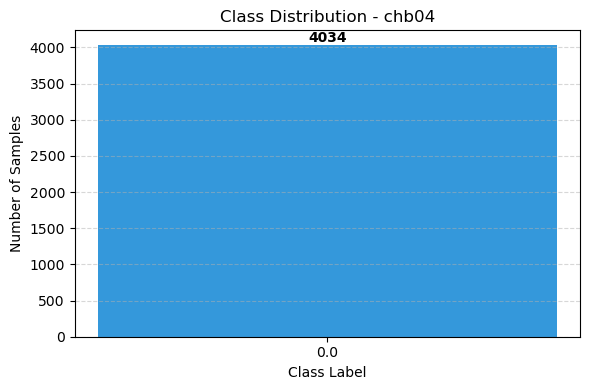

--- Class Distribution - chb12 ---
Class 0.0: 2086 samples (99.33%)
Class 1.0: 14 samples (0.67%)


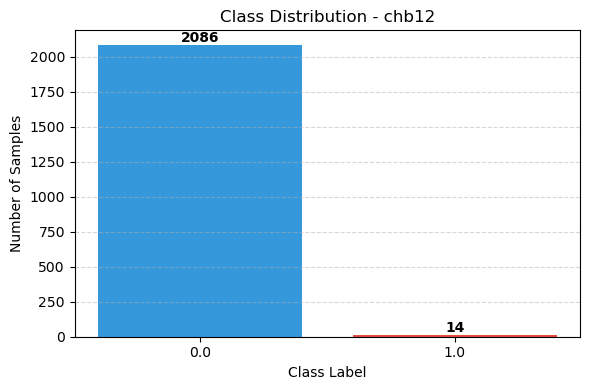

--- Class Distribution - chb13 ---
Class 0.0: 1709 samples (98.44%)
Class 1.0: 27 samples (1.56%)


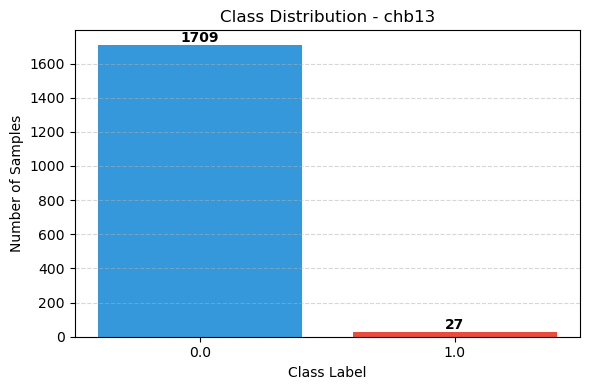

--- Class Distribution - chb19 ---
Class 0.0: 601 samples (94.65%)
Class 1.0: 34 samples (5.35%)


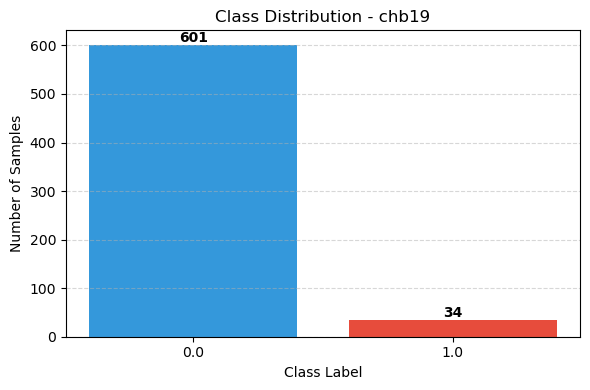

In [10]:
from utils.exploration.processed_data import get_agglomerated_labels, plot_class_distribution

for subj_name in tqdm(SUBJECTS_DIRECTORIES.keys(), desc="Evaluating Subjects"):
    # store data to explore label distribution
    subj_files = [DATA_PATH / subj_name / f"{f}.npz" for f in SUBJECTS_DIRECTORIES[subj_name]]
    y_labels_total = get_agglomerated_labels(subj_files, label_key='y_test')

    plot_class_distribution(
            labels=y_labels_total, 
            title=f'Class Distribution - {subj_name}',
            save=False,
        )

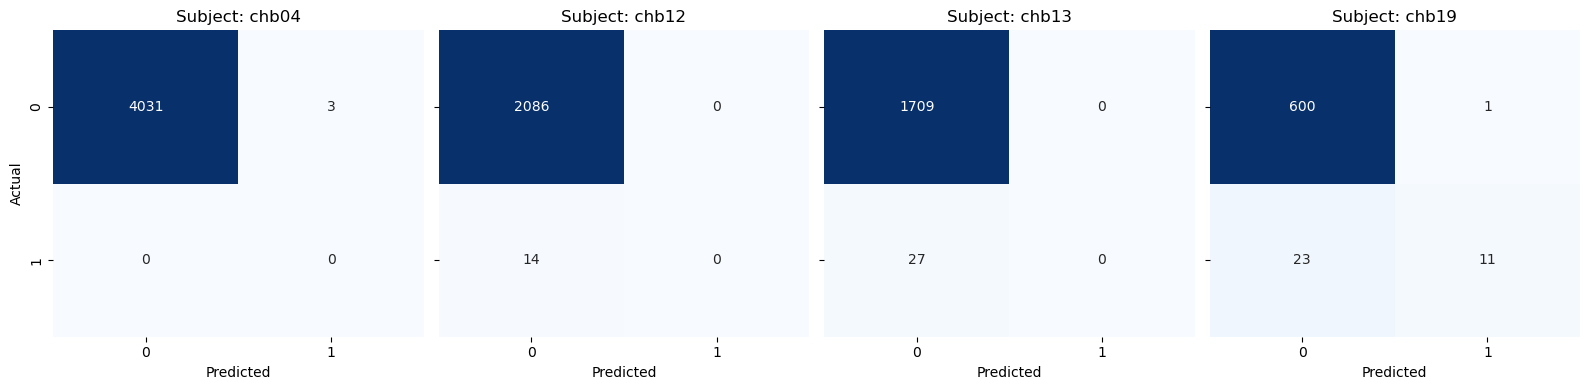

In [11]:

plot_all_confusion_matrices(eval_data, save=SAVE, path=SAVE_PLOT_PATH / "task1_comparison_confusion_matrices.png")

> These are realistic recordings. Since we use the final 15% of each patient's data for testing, many subjects have very few seizures in this period. This explains the strong class imbalance in the confusion matrices. Despite this, the model shows a solid ability to identify the **"Non-Seizure" (Inter-ictal)** class across all subjects.

### Cross-Subject Generalization Heatmap
Visualizes all performance metrics across all subjects in a single heatmap. This facilitates the identification of subjects where the model performance degrades, highlighting the limits of the model's generalization.

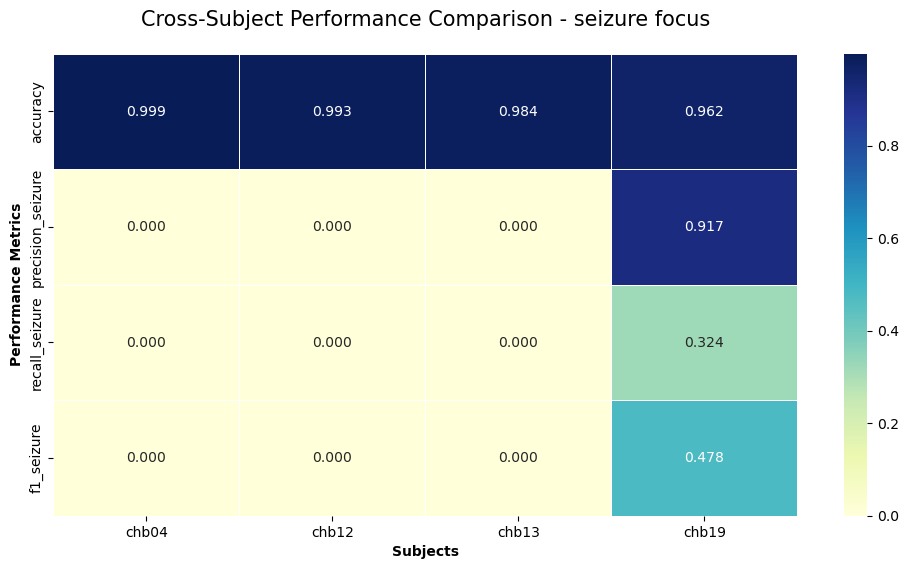

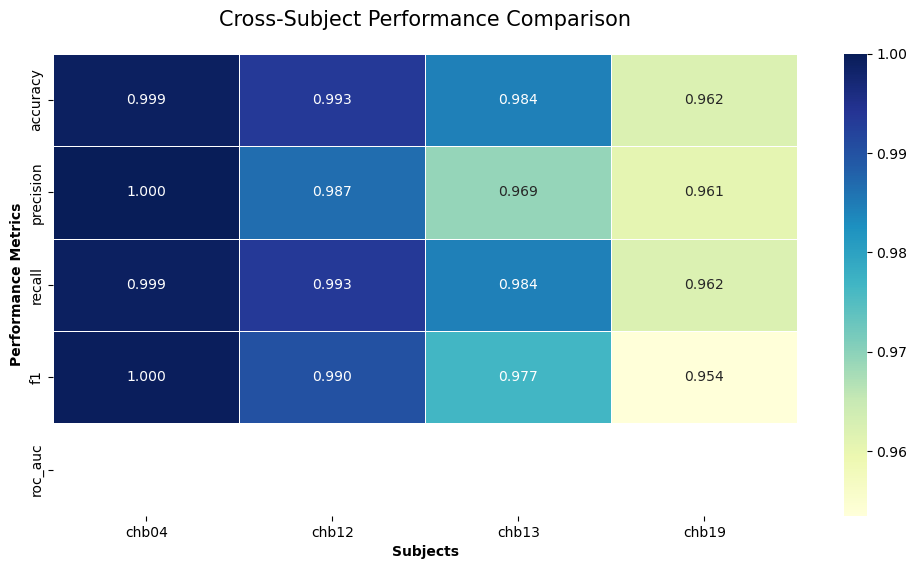

In [12]:
plot_subjects_metrics_heatmap(results_df, metrics_cols=["accuracy", "precision_seizure", "recall_seizure", "f1_seizure"], title = "Cross-Subject Performance Comparison - seizure focus")
plot_subjects_metrics_heatmap(results_df, save=SAVE, path=SAVE_PLOT_PATH / "task1_comparison_metrics_heatmap.png")

- The first heatmap shows near-zero scores because it focuses strictly on the seizure class (`pos_label=1`). In realistic test data, seizures are extremely rare, making them very hard to predict.

- The second heatmap shows high performance because it uses `average='weighted'`. This metric is dominated by the **"Non-Seizure" class**, which represents the majority of the data. High scores here mean the model is excellent at identifying normal brain activity, but the gap between the two heatmaps proves that identifying the actual seizure onset remains the primary challenge.

The model generalizes best on `chb04` (Male, 22y), our training subject. Interestingly, performance drops significantly for `chb19` (Female, 19y) despite the similar age, suggesting that _gender or specific seizure morphology varies_.

 Furthermore, the model performs very well on very young subjects like chb12 (Female, 2y) and chb13 (Female, 3y) in the weighted metrics, despite their different sex and age. This is a "false positive" sense of performance: because these specific test recordings contain almost no seizure events, the model achieves high accuracy simply by predicting "No Seizure" all the time. While it looks successful in the second plot, the first plot confirms it is _completely blind_ to the actual seizure patterns of toddlers.